In [1]:
import torch
import matplotlib.pyplot as plt
from typing import Tuple 
import os
import matplotlib.pyplot as plt
from skfmm import distance
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
import preprocess_dataset
import losses
from main_network import DecompositionNetwork
import importlib
importlib.reload(losses)
from tqdm import tqdm

In [2]:
# Hyperparameters:
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 3
LOAD_MODEL = False
NUM_WORKERS = os.cpu_count()


In [3]:
train_dataset = preprocess_dataset.OxfordIIITPet_Distancefields_train()
test_dataset = preprocess_dataset.OxfordIIITPet_Distancefields_test()

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataLoader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [5]:
def train(loader, model, optimizer, loss_fn, scaler):
    model = model.to(device=DEVICE)

    # data is rgb without background taken out
    # target is in first dim the y_mask and second dim is distance field
    for data, targets in (pbar := tqdm(loader)):
        # take out the background by applying GT mask
        masked_data = preprocess_dataset.mask_rgb_imgs(data, targets)
        masked_data = masked_data.to(device=DEVICE)
        targets = targets.float().to(device=DEVICE)


        # forward pass
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(
                predictions, 
                mask_y=torch.squeeze(targets[:][0][0]),
                field_y=torch.squeeze(targets[:][0][1])
                )

        # backward pass
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update tqdm loop
        pbar.set_postfix(loss=loss.item())

In [6]:
model = DecompositionNetwork()
optim = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()

for epoch in range(NUM_EPOCHS):
    train(train_dataloader, model, optim, losses.all_loss_fn, scaler)

model.to(device="cpu")
torch.cuda.empty_cache()

  0%|          | 0/230 [00:02<?, ?it/s]


NotImplementedError: 

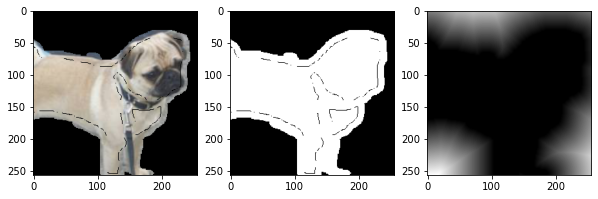

In [ ]:
_, ax = plt.subplots(1,3, figsize=(10,10))
for x,y in train_dataloader:
    x_masked = preprocess_dataset.mask_rgb_imgs(x,y)
    ax[0].imshow(torch.permute(x_masked[0], (1,2,0)), cmap="gray")
    ax[1].imshow(torch.squeeze(y[0][0]), cmap="gray")
    ax[2].imshow(torch.squeeze(y[0][1]), cmap="gray")
    break